In [2]:
import pandas as pd

listing = pd.read_csv("../data/raw/yapo_listing_raw.csv")
detail  = pd.read_csv("../data/raw/yapo_detail_raw.csv")

print("LISTING:", listing.shape)
print(listing.columns.tolist())
print("\nDETAIL:", detail.shape)
print(detail.columns.tolist())

# ¿Cuántos IDs coinciden entre ambos?
print("\nIDs en común:", listing['id'].isin(detail['id']).sum())
print("IDs solo en listing:", (~listing['id'].isin(detail['id'])).sum())


LISTING: (15102, 12)
['id', 'titulo', 'precio_clp', 'año', 'combustible', 'transmision', 'kilometraje', 'vendedor', 'region', 'destacado', 'url', 'fecha_scraping']

DETAIL: (15102, 10)
['id', 'fecha_publicacion', 'comuna', 'marca', 'modelo', 'empresa', 'direccion', 'tipo_vendedor', 'descripcion', 'error']

IDs en común: 15102
IDs solo en listing: 0


In [4]:
# Verifica que los nuevos tienen detalle
df_listing = pd.read_csv('../data/raw/yapo_listing_raw.csv')
df_detail  = pd.read_csv('../data/raw/yapo_detail_raw.csv')

sin_detalle = df_listing[~df_listing['id'].astype(str).isin(df_detail['id'].astype(str))]
print(f"Sin detalle: {len(sin_detalle)}")


Sin detalle: 0


In [8]:
df_listing = pd.read_csv('../data/raw/yapo_listing_raw.csv')
df_detail  = pd.read_csv('../data/raw/yapo_detail_raw.csv')

# Extrae los IDs de las URLs que copiaste manualmente
urls_manual = [
    "https://www.yapo.cl/autos-usados/chery-tiggo-3-pro-1-5t-glx-cvt-2023-3582/32087517",  # pega las 5 URLs aquí
    "https://www.yapo.cl/autos-usados/peugeot-208-automatico-bluetooth/31948237",
    "https://www.yapo.cl/autos-usados/peugeot-2008/32087472",
    "https://www.yapo.cl/autos-usados/vendo-por-renovacion/32087450",
    "https://www.yapo.cl/autos-usados/vendo-por-renovacion/32087450"
]
ids_manual = [u.split('/')[-1] for u in urls_manual]

for id_ in ids_manual:
    en_listing = id_ in df_listing['id'].astype(str).values
    en_detail  = id_ in df_detail['id'].astype(str).values
    print(f"ID {id_}: listing={en_listing} | detail={en_detail}")


ID 32087517: listing=True | detail=True
ID 31948237: listing=True | detail=True
ID 32087472: listing=True | detail=True
ID 32087450: listing=True | detail=True
ID 32087450: listing=True | detail=True


In [6]:


# Cuántos errores hay
errores = df[df['error'].notna()]
print(f"Total errores: {len(errores)}")
print(errores['error'].value_counts())


Total errores: 16
error
HTTP 500                                                                                                                                                                                                                                                                                                         7
HTTPSConnectionPool(host='www.yapo.cl', port=443): Read timed out. (read timeout=15)                                                                                                                                                                                                                             5
HTTPSConnectionPool(host='www.yapo.cl', port=443): Max retries exceeded with url: /autos-usados/dongfeng-joyear-s50-2022/28023623 (Caused by NameResolutionError("HTTPSConnection(host='www.yapo.cl', port=443): Failed to resolve 'www.yapo.cl' ([Errno -3] Temporary failure in name resolution)"))            1
HTTP 502                                               

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path("..") 
df = pd.read_csv(ROOT / "data/raw/yapo_full_raw.csv")

print(df.shape)
df.head(3)


(14909, 21)


,id,titulo,precio_clp,año,combustible,transmision,kilometraje,vendedor,region,destacado,...,fecha_scraping,fecha_publicacion,comuna,marca,modelo,empresa,direccion,tipo_vendedor,descripcion,error
0,32079793,BMW 320 IA AÑO 2010,$5.780.000,2010,Bencina,Automática,122690 km,Juan Pablo HZ,region-metropolitana,False,...,2026-03-05,05/03/2026,Ñuñoa,BMW,320,Diagonal Autos,"Presidente Jose Batlle y Ordoñez 3701, Ñuñoa, ...",NaN,"BMW 320 IA 2.0 AT AÑO 2010PRECIO OCASIÓN, VEHI...",NaN
1,32079731,focos neblineros peugeot 308 2012 t7,$35.000,2012,Bencina,Manual,NaN,_15111731 Lucero,region-metropolitana,False,...,2026-03-05,05/03/2026,Maipú,Peugeot,308,NaN,NaN,NaN,focos neblineros marca depo,NaN
2,32079630,2015 Peugeot 208 ALLURE E HDI 1.6,$9.280.000,2015,Diesel,Automática,54997 km,Pedro Pelayo,region-metropolitana,False,...,2026-03-05,05/03/2026,La Reina,Peugeot,208,Automoviles pelayo ltda,AVDA OSSA 315 LA REINA -,NaN,UNICO DUEÑOCOPIA DE LLAVEEXCELENTE ESTADOCIERR...,NaN


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 14909 entries, 0 to 14908
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 14909 non-null  int64
 1   titulo             14908 non-null  str  
 2   precio_clp         14700 non-null  str  
 3   año                14908 non-null  str  
 4   combustible        14908 non-null  str  
 5   transmision        14903 non-null  str  
 6   kilometraje        14592 non-null  str  
 7   vendedor           14907 non-null  str  
 8   region             14909 non-null  str  
 9   destacado          14909 non-null  bool 
 10  url                14909 non-null  str  
 11  fecha_scraping     14909 non-null  str  
 12  fecha_publicacion  14828 non-null  str  
 13  comuna             14828 non-null  str  
 14  marca              14691 non-null  str  
 15  modelo             14833 non-null  str  
 16  empresa            11371 non-null  str  
 17  direccion          642 

In [7]:
nulos = df.isnull().sum().sort_values(ascending=False)
pct   = (nulos / len(df) * 100).round(1)
pd.DataFrame({'nulos': nulos, '%': pct})[nulos > 0]


,nulos,%
error,14893,99.9
tipo_vendedor,14866,99.7
direccion,14267,95.7
empresa,3538,23.7
descripcion,883,5.9
kilometraje,317,2.1
marca,218,1.5
precio_clp,209,1.4
fecha_publicacion,81,0.5
comuna,81,0.5


In [8]:
# Todavía son strings, así que forzamos conversión temporal para ver rangos
cols = ['precio_clp', 'kilometraje', 'año']
for col in cols:
    serie = (df[col].astype(str)
             .str.replace(r"[^\d]", "", regex=True)
             .pipe(pd.to_numeric, errors='coerce'))
    print(f"\n── {col} ──")
    print(serie.describe())
    print(f"Nulos: {serie.isna().sum()}")



── precio_clp ──
count    1.470000e+04
mean     6.525226e+07
std      5.193435e+08
min      1.000000e+00
25%      6.000000e+06
50%      9.980000e+06
75%      1.860500e+07
max      5.300000e+10
Name: precio_clp, dtype: float64
Nulos: 209

── kilometraje ──
count    1.459200e+04
mean     1.437565e+05
std      1.588561e+06
min      1.000000e+00
25%      4.850000e+04
50%      9.850000e+04
75%      1.590225e+05
max      1.111111e+08
Name: kilometraje, dtype: float64
Nulos: 317

── año ──
count    14903.000000
mean      2015.699591
std          6.955512
min       1920.000000
25%       2012.000000
50%       2017.000000
75%       2021.000000
max       2026.000000
Name: año, dtype: float64
Nulos: 6


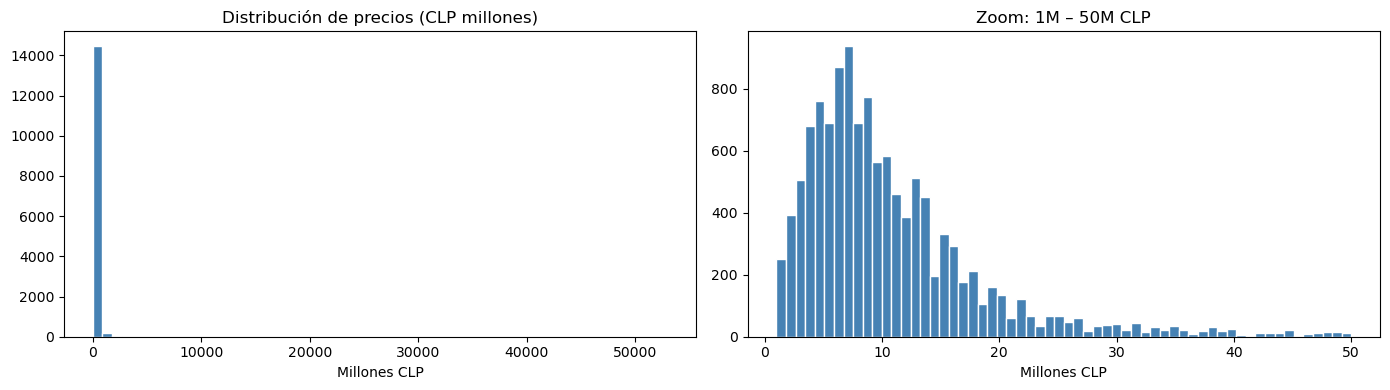

Precios sobre 50M: 392
Precios bajo 1M:   245


In [7]:
precio = (df['precio_clp'].astype(str)
          .str.replace(r"[^\d]", "", regex=True)
          .pipe(pd.to_numeric, errors='coerce')
          .dropna())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(precio / 1_000_000, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title("Distribución de precios (CLP millones)")
axes[0].set_xlabel("Millones CLP")

axes[1].hist(precio[precio.between(1e6, 5e7)] / 1_000_000, 
             bins=60, color='steelblue', edgecolor='white')
axes[1].set_title("Zoom: 1M – 50M CLP")
axes[1].set_xlabel("Millones CLP")

plt.tight_layout()
plt.show()
print(f"Precios sobre 50M: {(precio > 550_000_000).sum()}")
print(f"Precios bajo 1M:   {(precio < 1_000_000).sum()}")


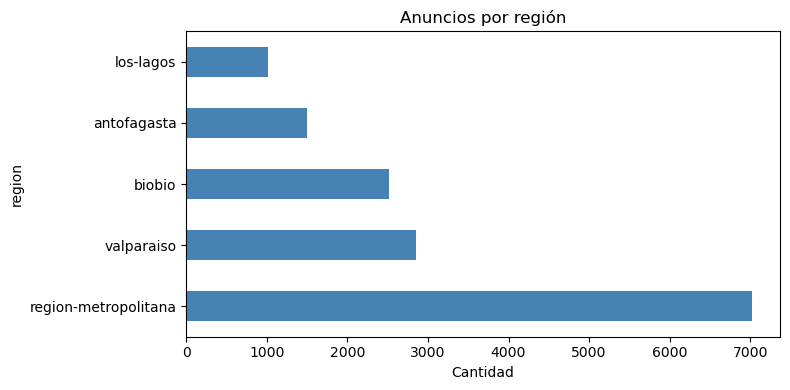

In [10]:
df['region'].value_counts().plot(kind='barh', figsize=(8,4), color='steelblue')
plt.title("Anuncios por región")
plt.xlabel("Cantidad")
plt.tight_layout()
plt.show()


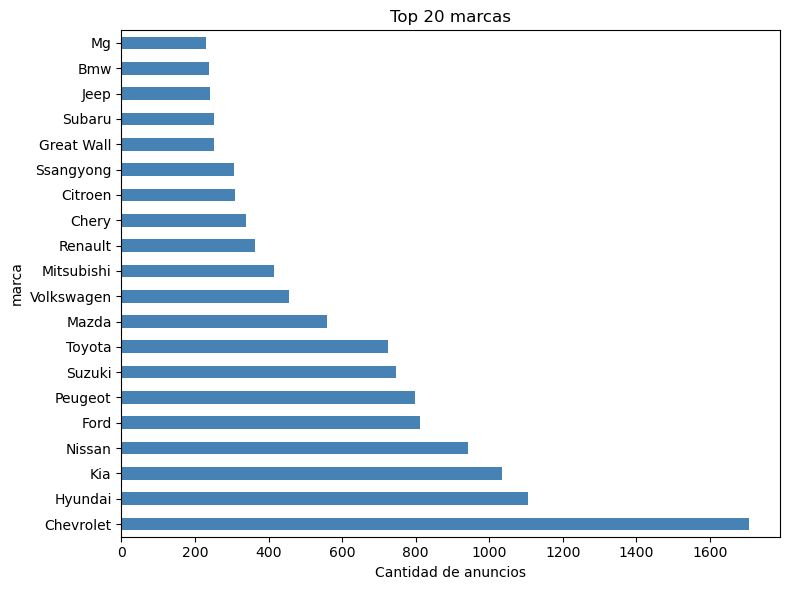

In [11]:
df['marca'].str.strip().str.title().value_counts().head(20).plot(
    kind='barh', figsize=(8,6), color='steelblue')
plt.title("Top 20 marcas")
plt.xlabel("Cantidad de anuncios")
plt.tight_layout()
plt.show()


In [8]:
raw   = pd.read_csv("../data/raw/yapo_full_raw.csv")
clean = pd.read_csv("../data/processed/yapo_clean.csv")

eliminados = len(raw) - len(clean)
print(f"Registros raw:     {len(raw):,}")
print(f"Registros limpios: {len(clean):,}")
print(f"Eliminados:        {eliminados:,} ({eliminados/len(raw)*100:.1f}%)")


Registros raw:     14,909
Registros limpios: 13,448
Eliminados:        1,461 (9.8%)
